In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d gpreda/bbc-news

Dataset URL: https://www.kaggle.com/datasets/gpreda/bbc-news
License(s): CC0-1.0
  0% 0.00/3.64M [00:00<?, ?B/s]
100% 3.64M/3.64M [00:00<00:00, 709MB/s]


In [ ]:
!unzip /content/bbc-news.zip

Archive:  /content/bbc-news.zip
  inflating: bbc_news.csv            


### Exploratory Data Analysis

In [ ]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
df = pd.read_csv("/content/bbc_news.csv")
df.head()

,title,pubDate,guid,link,description
0,Ukraine: Angry Zelensky vows to punish Russian...,"Mon, 07 Mar 2022 08:01:56 GMT",https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Sun, 06 Mar 2022 22:49:58 GMT",https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',"Mon, 07 Mar 2022 00:14:42 GMT",https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,"Mon, 07 Mar 2022 00:05:40 GMT",https://www.bbc.co.uk/news/uk-60579079,https://www.bbc.co.uk/news/uk-60579079?at_medi...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,"Mon, 07 Mar 2022 08:15:53 GMT",https://www.bbc.co.uk/news/business-60642786,https://www.bbc.co.uk/news/business-60642786?a...,Consumers are feeling the impact of higher ene...


In [ ]:
df['text'] = df['title'].fillna('') + ' ' + df['description'].fillna('')
df = df[['text']]
df.head()

,text
0,Ukraine: Angry Zelensky vows to punish Russian...
1,War in Ukraine: Taking cover in a town under a...
2,Ukraine war 'catastrophic for global food' One...
3,Manchester Arena bombing: Saffie Roussos's par...
4,Ukraine conflict: Oil price soars to highest l...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42115 entries, 0 to 42114
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    42115 non-null  object
dtypes: object(1)
memory usage: 329.2+ KB


In [ ]:
df.describe()

,text
count,42115
unique,40111
top,Election poll tracker: How do the parties comp...
freq,34


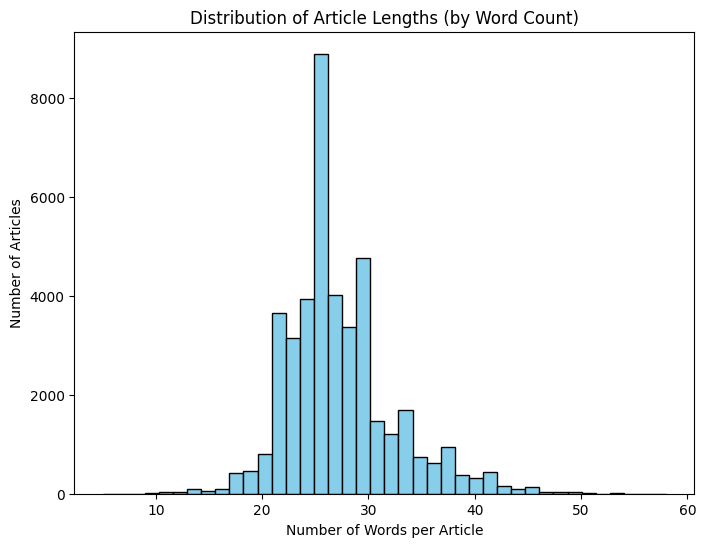

In [ ]:
import matplotlib.pyplot as plt

word_count = df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 6))
plt.hist(word_count, bins=40, color='skyblue', edgecolor='black')
plt.title('Distribution of Article Lengths (by Word Count)')
plt.xlabel('Number of Words per Article')
plt.ylabel('Number of Articles')
plt.show()


### Text Preprocessing

In [ ]:
def to_lower(text):
 text = text.lower()
 return text
df["text"] = df["text"].apply(to_lower)
df.head()


,text
0,ukraine: angry zelensky vows to punish russian...
1,war in ukraine: taking cover in a town under a...
2,ukraine war 'catastrophic for global food' one...
3,manchester arena bombing: saffie roussos's par...
4,ukraine conflict: oil price soars to highest l...


In [ ]:
import string
def remove_punctuation(text):
  text =text.translate(str.maketrans("", "", string.punctuation))
  return text
df ['text'] = df['text'].apply(remove_punctuation)

df.head()

,text
0,ukraine angry zelensky vows to punish russian ...
1,war in ukraine taking cover in a town under at...
2,ukraine war catastrophic for global food one o...
3,manchester arena bombing saffie roussoss paren...
4,ukraine conflict oil price soars to highest le...


In [ ]:
def remove_special_char(text):
  text= re.sub(r"[^A-Za-z]"," ", text)
  return text
df["text"] = df["text"].apply(remove_special_char)
df.head()

,text
0,ukraine angry zelensky vows to punish russian ...
1,war in ukraine taking cover in a town under at...
2,ukraine war catastrophic for global food one o...
3,manchester arena bombing saffie roussoss paren...
4,ukraine conflict oil price soars to highest le...


In [ ]:
def normalize_repeated_chars(text):
  text = re.sub(r"(.)\1{2,}", r"\1\1", text)
  return text.strip()
df["text"] = df["text"].apply(normalize_repeated_chars)
df.head()

,text
0,ukraine angry zelensky vows to punish russian ...
1,war in ukraine taking cover in a town under at...
2,ukraine war catastrophic for global food one o...
3,manchester arena bombing saffie roussoss paren...
4,ukraine conflict oil price soars to highest le...


In [ ]:

from nltk.tokenize import word_tokenize

def tokenize_text(text):
  tokens = word_tokenize(text)
  return tokens

tokens = df['text'].apply(tokenize_text)
tokens.head()

,text
0,"[ukraine, angry, zelensky, vows, to, punish, r..."
1,"[war, in, ukraine, taking, cover, in, a, town,..."
2,"[ukraine, war, catastrophic, for, global, food..."
3,"[manchester, arena, bombing, saffie, roussoss,..."
4,"[ukraine, conflict, oil, price, soars, to, hig..."


In [ ]:

def remove_stopwords(tokens: list) -> list:

    all_stop_words = set(stopwords.words('english'))

    filtered_tokens = [
        token for token in tokens
        if token.lower() not in all_stop_words
    ]

    return filtered_tokens

filtered_tokens = tokens.apply(remove_stopwords)

In [ ]:
def get_wordnet_pos(treebank_tag):
   if treebank_tag.startswith('J'):
        return wordnet.ADJ
   elif treebank_tag.startswith('V'):
        return wordnet.VERB
   elif treebank_tag.startswith('N'):
        return wordnet.NOUN
   elif treebank_tag.startswith('R'):
        return wordnet.ADV
   else:
        return wordnet.NOUN


In [ ]:
def lemmatize_tokens_list(tokens):

   lem = WordNetLemmatizer()
   pos_tags= nltk.pos_tag(tokens)
   lemmatized = [lem.lemmatize(word, get_wordnet_pos(pos)) for word, pos in pos_tags ]
   return lemmatized

lemmatized_tokens = filtered_tokens.apply(lemmatize_tokens_list)
lemmatized_tokens.head()



,text
0,"[ukraine, angry, zelensky, vow, punish, russia..."
1,"[war, ukraine, take, cover, town, attack, jere..."
2,"[ukraine, war, catastrophic, global, food, one..."
3,"[manchester, arena, bomb, saffie, roussoss, pa..."
4,"[ukraine, conflict, oil, price, soar, high, le..."


In [ ]:
df.loc[:, 'text'] = lemmatized_tokens.apply(lambda x: ' '.join(x))

df.head()


,text
0,ukraine angry zelensky vow punish russian atro...
1,war ukraine take cover town attack jeremy bowe...
2,ukraine war catastrophic global food one world...
3,manchester arena bomb saffie roussoss parent h...
4,ukraine conflict oil price soar high level sin...


In [ ]:
texts = lemmatized_tokens.tolist()
docs = df['text'].tolist()
print(f"Number of documents: {len(texts)}")
print(f"Sample processed text: {texts[0][:10]}")

Number of documents: 42115
Sample processed text: ['ukraine', 'angry', 'zelensky', 'vow', 'punish', 'russian', 'atrocity', 'ukrainian', 'president', 'say']


In [ ]:
from gensim import corpora

dictionary = corpora.Dictionary(texts)
print(f" Dictionary created with {len(dictionary)} unique tokens before filtering.")

dictionary.filter_extremes(
    no_below=2,
    no_above=0.8,
    keep_n=1000
)
print(f" After filtering: {len(dictionary)} unique tokens remain.")


 Dictionary created with 34518 unique tokens before filtering.
 After filtering: 1000 unique tokens remain.


In [ ]:
corpus = [dictionary.doc2bow(text) for text in texts]

print(f" Corpus created successfully with {len(corpus)} documents.")

 Corpus created successfully with 42115 documents.


In [ ]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split

def find_optimal_topics(texts, min_topics=2, max_topics=10, max_features=1000, test_size=0.2, random_state=42):

    train_texts, test_texts = train_test_split(texts, test_size=test_size, random_state=random_state)

    vectorizer = CountVectorizer(
        max_features=max_features,
        min_df=2,
        max_df=0.8,
        stop_words='english'
    )
    train_dtm = vectorizer.fit_transform(train_texts)
    test_dtm = vectorizer.transform(test_texts)

    perplexity_scores = []
    topic_range = range(min_topics, max_topics + 1)

    for n_topics in topic_range:
        print(f"🔹 Training model with {n_topics} topics...")

        lda = LatentDirichletAllocation(
            n_components=n_topics,
            random_state=random_state,
            max_iter=20,
            learning_method='batch'
        )

        lda.fit(train_dtm)

        perplexity = lda.perplexity(test_dtm)
        perplexity_scores.append(perplexity)
        print(f"   → Perplexity = {perplexity:.2f}")

    plt.figure(figsize=(10, 6))
    plt.plot(topic_range, perplexity_scores, marker='o', color='royalblue')
    plt.xlabel('Number of (Topics)')
    plt.ylabel('Value of Perplexity')
    plt.grid(True)

    best_idx = np.argmin(perplexity_scores)
    best_n_topics = list(topic_range)[best_idx]
    plt.scatter(best_n_topics, perplexity_scores[best_idx], color='red', s=100, label=f'Best = {best_n_topics}')
    plt.legend()
    plt.show()

    print(f"\n Best number of topics: {best_n_topics} ( Perplexity = {perplexity_scores[best_idx]:.2f})")

    return best_n_topics, perplexity_scores, vectorizer, train_dtm, test_dtm


🔹 Training model with 2 topics...
   → Perplexity = 663.74
🔹 Training model with 3 topics...
   → Perplexity = 648.46
🔹 Training model with 4 topics...
   → Perplexity = 644.21
🔹 Training model with 5 topics...
   → Perplexity = 638.38
🔹 Training model with 6 topics...
   → Perplexity = 643.97
🔹 Training model with 7 topics...
   → Perplexity = 658.74
🔹 Training model with 8 topics...
   → Perplexity = 660.87
🔹 Training model with 9 topics...
   → Perplexity = 659.56
🔹 Training model with 10 topics...
   → Perplexity = 661.60


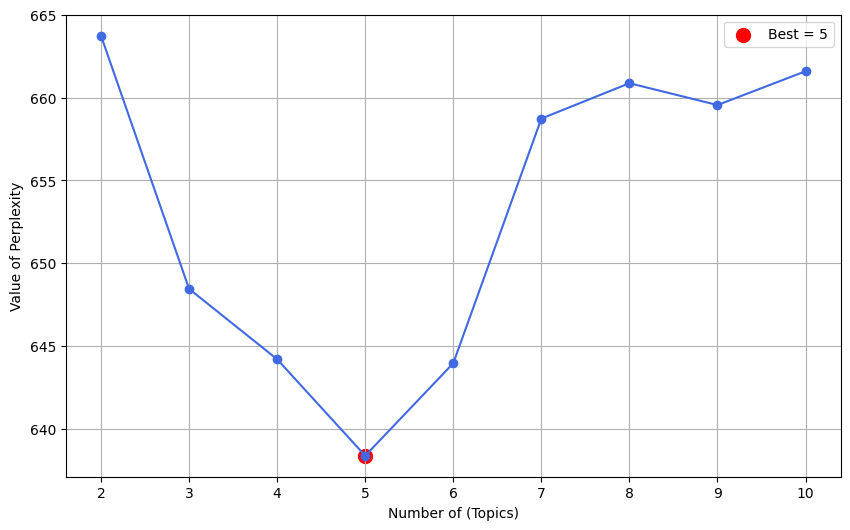


 Best number of topics: 5 ( Perplexity = 638.38)


In [ ]:
best_n, scores, vectorizer, train_dtm, test_dtm = find_optimal_topics(df['text'])


In [ ]:
# Train the final model
print(f"\nTraining final LDA model with {best_n} topics...")
final_model = LatentDirichletAllocation(
    n_components=best_n,
    random_state=42,
    max_iter=20
)


Training final LDA model with 5 topics...


In [ ]:
# Train the final model
final_model.fit(train_dtm)


LatentDirichletAllocation(max_iter=20, n_components=5, random_state=42)

In [ ]:
def show_topics(model, feature_names, n_top_words=10):
    for idx, topic in enumerate(model.components_):
        print(f"\n Topic {idx + 1}:")
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(", ".join(top_words))

feature_names = vectorizer.get_feature_names_out()
show_topics(final_model, feature_names)



 Topic 1:
ukraine, war, election, say, russia, russian, president, year, trump, king

 Topic 2:
say, police, woman, die, death, man, kill, family, murder, court

 Topic 3:
say, strike, people, bbc, gaza, israel, school, home, attack, day

 Topic 4:
say, uk, rise, government, paper, minister, new, cost, plan, change

 Topic 5:
world, england, win, cup, league, final, manchester, beat, say, open


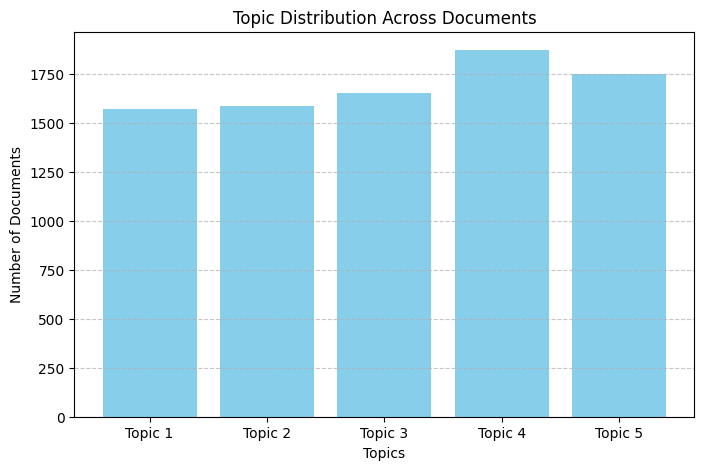

In [ ]:
import matplotlib.pyplot as plt
# Get topic distribution
doc_topic_dist = final_model.transform(test_dtm)
dominant_topics = np.argmax(doc_topic_dist, axis=1)

unique, counts = np.unique(dominant_topics, return_counts=True)

plt.figure(figsize=(8, 5))
plt.bar([f"Topic {i+1}" for i in unique], counts, color='skyblue')
plt.title("Topic Distribution Across Documents")
plt.xlabel("Topics")
plt.ylabel("Number of Documents")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


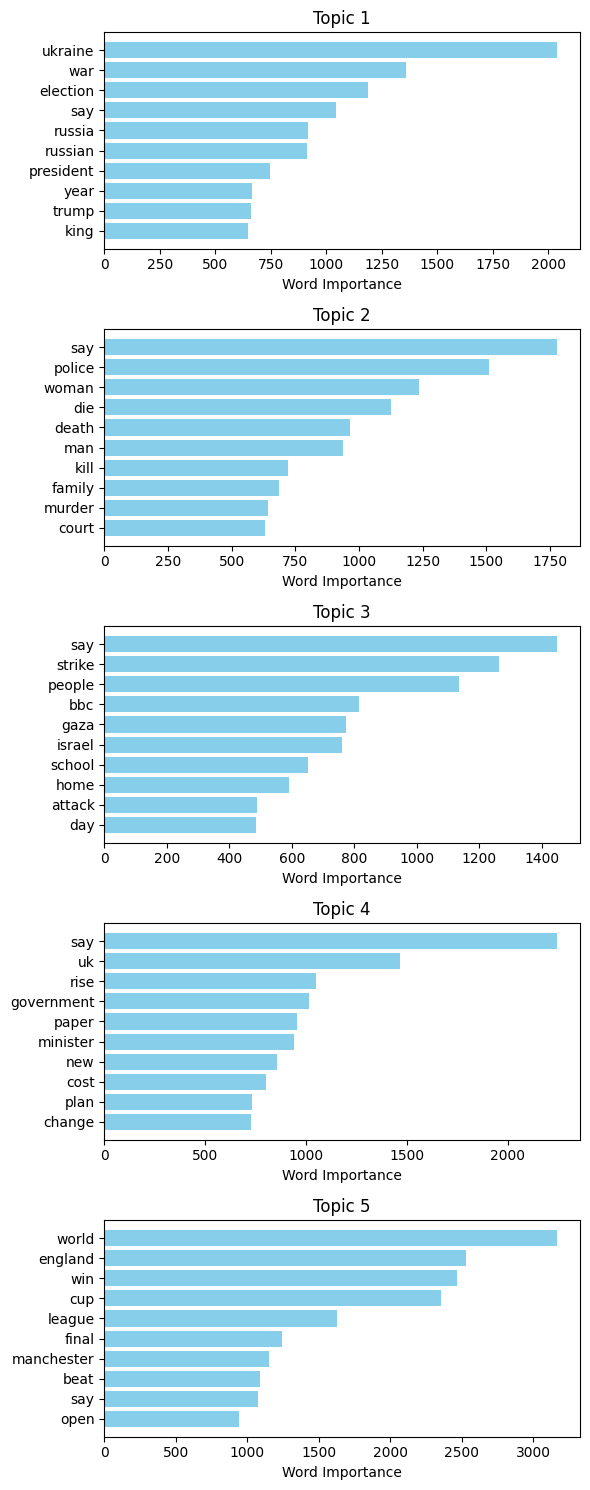

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_topics(model, feature_names, n_top_words=10):
    num_topics = model.components_.shape[0]
    fig, axes = plt.subplots(num_topics, 1, figsize=(6, 3 * num_topics))

    if num_topics == 1:
        axes = [axes]

    for idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        top_weights = topic[top_indices]

        axes[idx].barh(top_words[::-1], top_weights[::-1], color='skyblue')
        axes[idx].set_title(f"Topic {idx + 1}", fontsize=12)
        axes[idx].set_xlabel("Word Importance")

    plt.tight_layout()
    plt.show()
plot_topics(final_model, feature_names, n_top_words=10)


In [ ]:
topic_name_map = {
    1: "Russia–Ukraine War & Politics",
    2: "Police and Crime News",
    3: "Gaza–Israel War Coverage",
    4: "UK Politics & Economy",
    5: "Sports & Football News"
}

In [ ]:
doc_term_matrix_all = vectorizer.transform(df['text'].astype(str))
topic_distributions = final_model.transform(doc_term_matrix_all)  # shape: (n_docs, n_topics)
dominant_idx = np.argmax(topic_distributions, axis=1)  # 0-based

In [ ]:
n_topics = topic_distributions.shape[1]
name_for_index = {}
for i in range(n_topics):
    human_name = topic_name_map.get(i+1, f"Topic {i+1}")
    name_for_index[i] = human_name

In [ ]:
df = df.copy()
df['dominant_topic'] = dominant_idx + 1
df['dominant_topic_name'] = [name_for_index[i] for i in dominant_idx]
df['topic_probs'] = list(topic_distributions)

In [ ]:
unique, counts = np.unique(dominant_idx, return_counts=True)
total_docs = len(dominant_idx)

print("\nTopic Distribution Summary:")
print("=" * 30)
for idx, count in zip(unique, counts):
    pct = (count / total_docs) * 100
    print(f"Topic {idx+1}: {count} documents ({pct:.1f}%) — {name_for_index[idx]}")



Topic Distribution Summary:
Topic 1: 7632 documents (18.1%) — Russia–Ukraine War & Politics
Topic 2: 7679 documents (18.2%) — Police and Crime News
Topic 3: 8516 documents (20.2%) — Gaza–Israel War Coverage
Topic 4: 9291 documents (22.1%) — UK Politics & Economy
Topic 5: 8997 documents (21.4%) — Sports & Football News


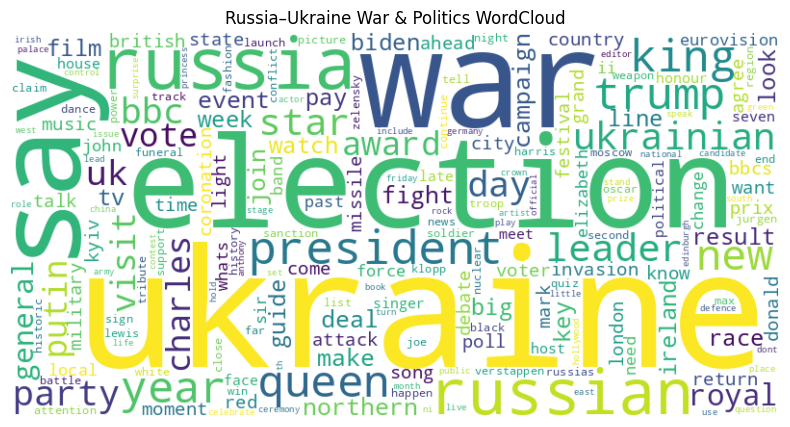

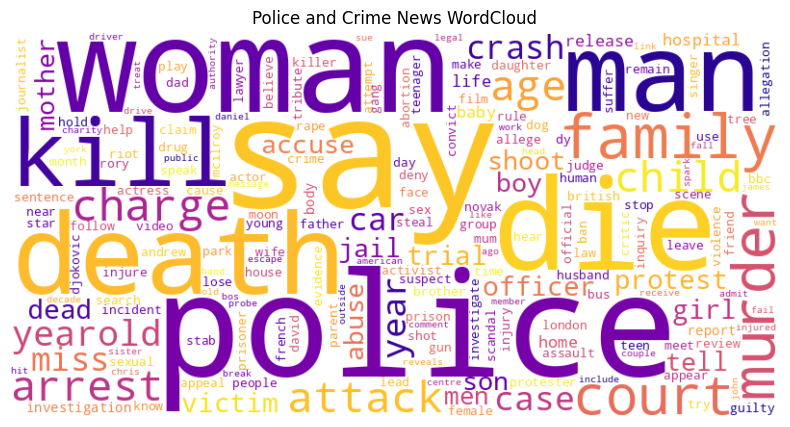

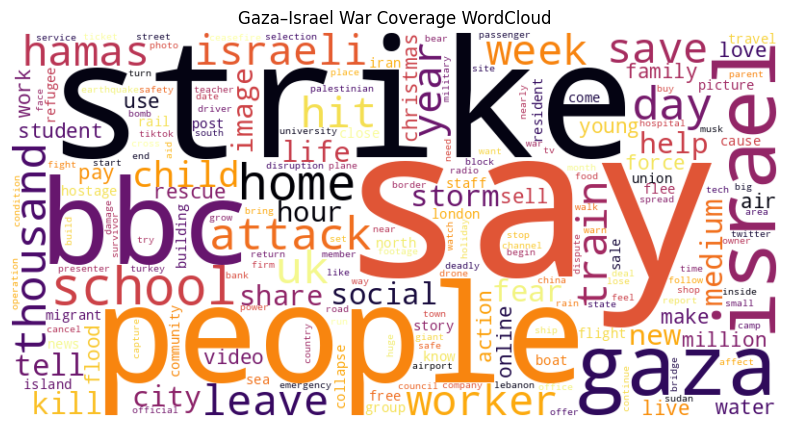

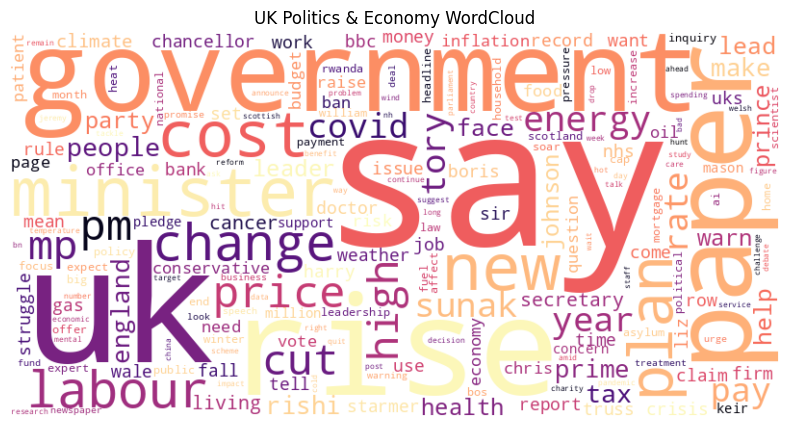

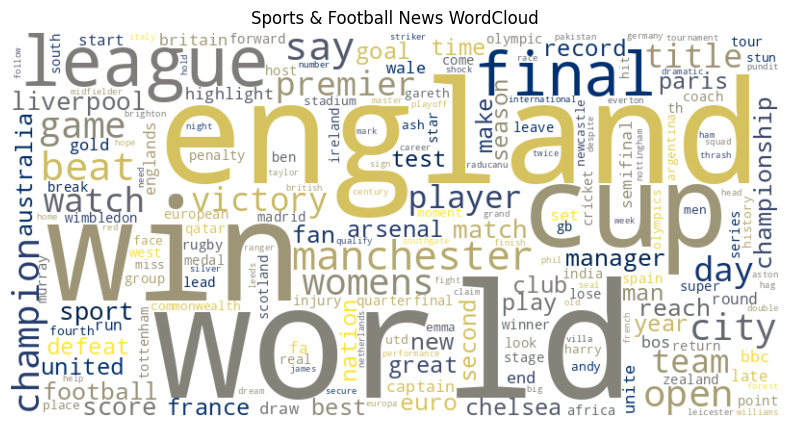

In [ ]:
from wordcloud import WordCloud

colors = ['viridis', 'plasma', 'inferno', 'magma', 'cividis']

def plot_all_topics_wordcloud(model, feature_names, topic_name_map, n_topics=None):
    if n_topics is None:
        n_topics = model.n_components

    for topic_idx in range(n_topics):
        word_weights = {feature_names[i]: model.components_[topic_idx, i]
                        for i in range(len(feature_names))}

        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color='white',
            colormap=colors[topic_idx % len(colors)]
        ).generate_from_frequencies(word_weights)

        plt.figure(figsize=(10,5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")
        topic_name = topic_name_map.get(topic_idx + 1, f"Topic #{topic_idx + 1}")
        plt.title(f"{topic_name} WordCloud")
        plt.show()

plot_all_topics_wordcloud(final_model, feature_names, topic_name_map)
